Import Cell


In [4]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
from IPython.display import display, HTML

nlp_lg = spacy.load("en_core_web_lg")
nlp_trf = spacy.load("en_core_web_trf")

nlp = nlp_lg

# Test sentences covering different similarity types
test_sentences = [
    # Direct copies and near-copies
    "The cat sat on the mat.",
    "The cat sat on the mat",
    "The  cat  sat  on  the  mat.",
    
    # Paraphrases
    "On the mat, the cat was sitting.",
    "The feline rested on the rug.",
    
    # Structural changes
    "The quick brown fox jumps over the lazy dog.",
    "Over the lazy dog jumps the quick brown fox.",
    
    # Different content
    "The dog ran in the park.",
    "I love programming.",
    "She enjoys reading books.",
    
    # Edge cases
    "Short.",
    "A B C D E F G",
    ""
]

print(f"Loaded {len(test_sentences)} test sentences")

Loaded 13 test sentences


,sentence_id,sentence,char_length,word_count,alpha_word_count,avg_word_length,has_punctuation,is_empty
0,0,The cat sat on the mat.,23,7,6,2.833333,True,False
1,1,The cat sat on the mat,22,6,6,2.833333,False,False
2,2,The cat sat on the mat.,28,7,6,2.833333,True,False
3,3,"On the mat, the cat was sitting.",32,9,7,3.428571,True,False
4,4,The feline rested on the rug.,29,7,6,3.833333,True,False
5,5,The quick brown fox jumps over the lazy dog.,44,10,9,3.888889,True,False
6,6,Over the lazy dog jumps the quick brown fox.,44,10,9,3.888889,True,False
7,7,The dog ran in the park.,24,7,6,3.000000,True,False
8,8,I love programming.,19,4,3,5.333333,True,False
9,9,She enjoys reading books.,25,5,4,5.250000,True,False


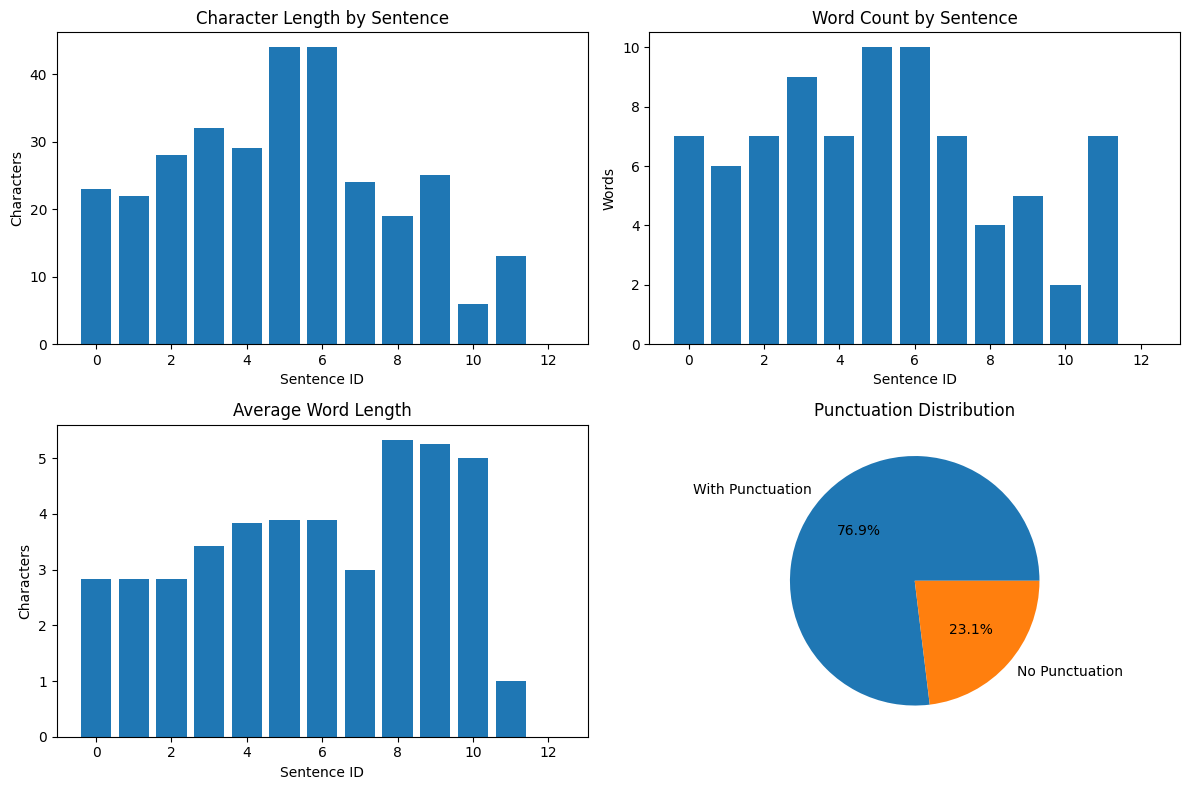

In [5]:
def analyze_text_statistics(sentences):
    stats = []
    for i, sent in enumerate(sentences):
        doc = nlp(sent)
        words = [token.text for token in doc if not token.is_space]
        alpha_words = [token.text for token in doc if token.is_alpha]
        
        stats.append({
            'sentence_id': i,
            'sentence': sent,
            'char_length': len(sent),
            'word_count': len(words),
            'alpha_word_count': len(alpha_words),
            'avg_word_length': np.mean([len(word) for word in alpha_words]) if alpha_words else 0,
            'has_punctuation': any(token.is_punct for token in doc),
            'is_empty': len(sent.strip()) == 0
        })
    
    return pd.DataFrame(stats)

stats_df = analyze_text_statistics(test_sentences)
display(stats_df)

# Visualize basic statistics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Character length distribution
axes[0,0].bar(range(len(stats_df)), stats_df['char_length'])
axes[0,0].set_title('Character Length by Sentence')
axes[0,0].set_xlabel('Sentence ID')
axes[0,0].set_ylabel('Characters')

# Word count distribution
axes[0,1].bar(range(len(stats_df)), stats_df['word_count'])
axes[0,1].set_title('Word Count by Sentence')
axes[0,1].set_xlabel('Sentence ID')
axes[0,1].set_ylabel('Words')

# Average word length
axes[1,0].bar(range(len(stats_df)), stats_df['avg_word_length'])
axes[1,0].set_title('Average Word Length')
axes[1,0].set_xlabel('Sentence ID')
axes[1,0].set_ylabel('Characters')

# Sentence type breakdown
types = ['With Punctuation' if x else 'No Punctuation' for x in stats_df['has_punctuation']]
type_counts = pd.Series(types).value_counts()
axes[1,1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Punctuation Distribution')

plt.tight_layout()
plt.show()

In [15]:

class TextPreprocessor:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_lg")
    
    def extract_linguistic_features(self, text):
        """ Extract linguistic features """
        doc = self.nlp(text)
        
        features = {
            'tokens': [token.text for token in doc],
            'lemmas': [token.lemma_ for token in doc if token.is_alpha],
            'pos_tags': [token.pos_ for token in doc],
            'dep_tags': [token.dep_ for token in doc],
            'is_stop': [token.is_stop for token in doc],
            'is_alpha': [token.is_alpha for token in doc],
            'is_punct': [token.is_punct for token in doc]
        }
        
        return features, doc
    
    def direct_preprocessing(self, text):
        """ For direct copy detection """
        return text.lower().strip()
    
    def semantic_preprocessing(self, text):
        """ For semantic similarity """
        # Remove noise like stop words
        doc = self.nlp(text)
        processed_tokens = []
        for token in doc:
            if not token.is_punct and not token.is_space and token.is_alpha and not token.is_stop:
                processed_tokens.append(token.lemma_.lower())
        return " ".join(processed_tokens)
    
    def syntactic_preprocessing(self, text):
        """ For syntactic similarity """
        # Normalize
        doc = self.nlp(text)
        processed_tokens = []
        for token in doc:
            if token.is_space:
                continue
            elif token.is_punct:
                processed_tokens.append(token.text)
            elif token.is_stop:
                processed_tokens.append(token.lemma_.lower())
            else:
                processed_tokens.append(token.lemma_.lower())
        return " ".join(processed_tokens)


# Initialize preprocessor
preprocessor = TextPreprocessor()

# Analyze all sentences
print("Linguistic Analysis")
print("=" * 60)

for i, sentence in enumerate(test_sentences):
    print(f"\n{i+1:2d}. {'ORIGINAL: ':<20}'{sentence}'")
    features, doc = preprocessor.extract_linguistic_features(sentence)
    
    print(f"    {'Direct:     ':<20}'{preprocessor.direct_preprocessing(sentence)}'")
    print(f"    {'Semantic:   ':<20}'{preprocessor.semantic_preprocessing(sentence)}'")
    print(f"    {'Syntactic:  ':<20}'{preprocessor.syntactic_preprocessing(sentence)}'")
    
    # Basic counts
    print(f"    {'Tokens: ':<20}{len(features['tokens']):2d} | "
          f"Alpha: {sum(features['is_alpha']):2d} | "
          f"Stopwords: {sum(features['is_stop']):2d} | "
          f"Punctuation: {sum(features['is_punct']):2d}")
    
    # POS distribution
    pos_counts = Counter(features['pos_tags'])
    print(f"    {'POS:':<20}{dict(pos_counts)}")

Linguistic Analysis

 1. ORIGINAL:           'The cat sat on the mat.'
    Direct:             'the cat sat on the mat.'
    Semantic:           'cat sit mat'
    Syntactic:          'the cat sit on the mat .'
    Tokens:              7 | Alpha:  6 | Stopwords:  3 | Punctuation:  1
    POS:                {'DET': 2, 'NOUN': 2, 'VERB': 1, 'ADP': 1, 'PUNCT': 1}

 2. ORIGINAL:           'The cat sat on the mat'
    Direct:             'the cat sat on the mat'
    Semantic:           'cat sit mat'
    Syntactic:          'the cat sit on the mat'
    Tokens:              6 | Alpha:  6 | Stopwords:  3 | Punctuation:  0
    POS:                {'DET': 2, 'NOUN': 2, 'VERB': 1, 'ADP': 1}

 3. ORIGINAL:           'The  cat  sat  on  the  mat.'
    Direct:             'the  cat  sat  on  the  mat.'
    Semantic:           'cat sit mat'
    Syntactic:          'the cat sit on the mat .'
    Tokens:             12 | Alpha:  6 | Stopwords:  3 | Punctuation:  1
    POS:                {'DET': 2, 'SPA

In [16]:

def analyze_dependency_structure(text, sentence_id):
    """Analyze and display dependency parse information"""
    if not text.strip():
        print(f"Sentence {sentence_id}: [EMPTY]")
        return None
    
    doc = nlp(text)
    
    print(f"\nSentence {sentence_id}: '{text}'")
    print("Dependency Parse:")
    print("-" * 50)
    
    # Extract dependency relationships
    dependencies = []
    for token in doc:
        dependencies.append({
            'token': token.text,
            'lemma': token.lemma_,
            'pos': token.pos_,
            'dep': token.dep_,
            'head': token.head.text,
            'children': [child.text for child in token.children]
        })
        print(f"{token.text:<12} {token.dep_:<12} {token.head.text:<12} {[child.text for child in token.children]}")
    
    return dependencies

def visualize_dependency_tree(text, sentence_id):
    """Create dependency tree visualization"""
    if not text.strip():
        return
    
    doc = nlp(text)
    
    # Use displacy for visualization
    from spacy import displacy
    
    print(f"\nDependency Tree Visualization - Sentence {sentence_id}:")
    html = displacy.render(doc, style="dep", jupyter=True, options={'distance': 120})
    
    return html

# Analyze dependency structures for key sentence pairs
key_pairs = [
    (0, "The cat sat on the mat."),
    (3, "On the mat, the cat was sitting."),
    (4, "The feline rested on the rug."),
    (5, "The quick brown fox jumps over the lazy dog.")
]

for sentence_id, sentence in key_pairs:
    deps = analyze_dependency_structure(sentence, sentence_id)
    visualize_dependency_tree(sentence, sentence_id)
    print("\n" + "="*70 + "\n")


Sentence 0: 'The cat sat on the mat.'
Dependency Parse:
--------------------------------------------------
The          det          cat          []
cat          nsubj        sat          ['The']
sat          ROOT         sat          ['cat', 'on', '.']
on           prep         sat          ['mat']
the          det          mat          []
mat          pobj         on           ['the']
.            punct        sat          []

Dependency Tree Visualization - Sentence 0:





Sentence 3: 'On the mat, the cat was sitting.'
Dependency Parse:
--------------------------------------------------
On           prep         sitting      ['mat']
the          det          mat          []
mat          pobj         On           ['the']
,            punct        sitting      []
the          det          cat          []
cat          nsubj        sitting      ['the']
was          aux          sitting      []
sitting      ROOT         sitting      ['On', ',', 'cat', 'was', '.']
.            punct        sitting      []

Dependency Tree Visualization - Sentence 3:





Sentence 4: 'The feline rested on the rug.'
Dependency Parse:
--------------------------------------------------
The          det          feline       []
feline       nsubj        rested       ['The']
rested       ROOT         rested       ['feline', 'on', '.']
on           prep         rested       ['rug']
the          det          rug          []
rug          pobj         on           ['the']
.            punct        rested       []

Dependency Tree Visualization - Sentence 4:





Sentence 5: 'The quick brown fox jumps over the lazy dog.'
Dependency Parse:
--------------------------------------------------
The          det          fox          []
quick        amod         fox          []
brown        amod         fox          []
fox          nsubj        jumps        ['The', 'quick', 'brown']
jumps        ROOT         jumps        ['fox', 'over', '.']
over         prep         jumps        ['dog']
the          det          dog          []
lazy         amod         dog          []
dog          pobj         over         ['the', 'lazy']
.            punct        jumps        []

Dependency Tree Visualization - Sentence 5:


VOCABULARY ANALYSIS
Total unique words: 35
Total unique lemmas: 34
Total content words: 21


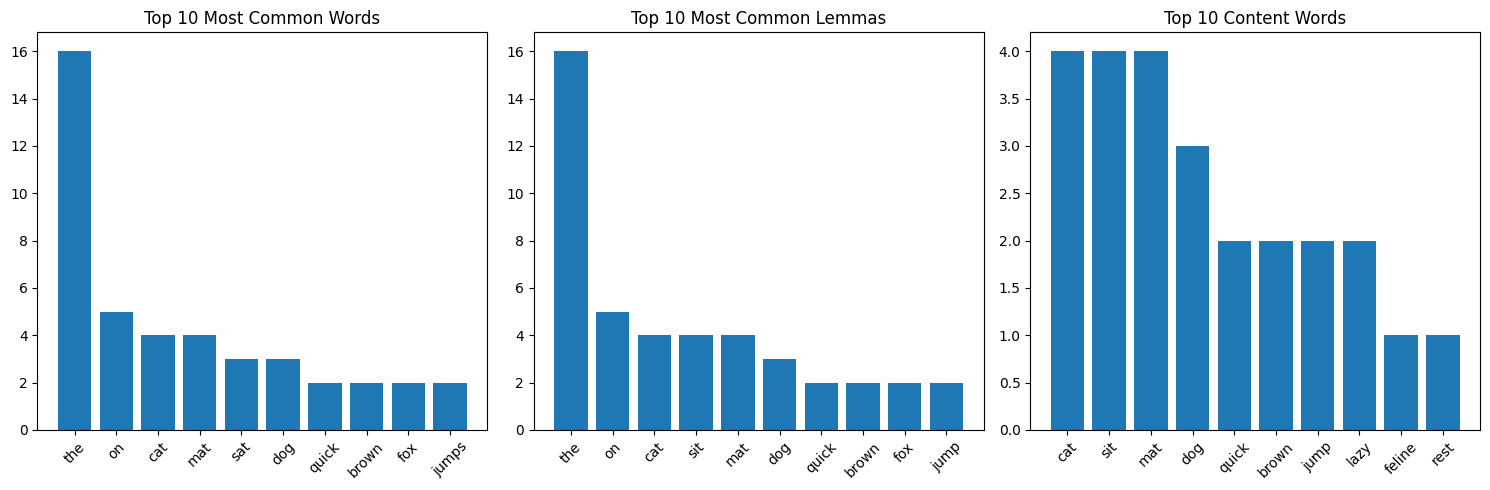

In [17]:
def analyze_vocabulary_distribution(sentences):
    """Analyze word frequencies and vocabulary across sentences"""
    all_words = []
    all_lemmas = []
    content_words = []
    
    for sent in sentences:
        doc = nlp(sent)
        for token in doc:
            if token.is_alpha and not token.is_space:
                all_words.append(token.text.lower())
                all_lemmas.append(token.lemma_.lower())
                if not token.is_stop and token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']:
                    content_words.append(token.lemma_.lower())
    
    # Calculate frequencies
    word_freq = Counter(all_words)
    lemma_freq = Counter(all_lemmas)
    content_freq = Counter(content_words)
    
    return word_freq, lemma_freq, content_freq

word_freq, lemma_freq, content_freq = analyze_vocabulary_distribution(test_sentences)

print("VOCABULARY ANALYSIS")
print("=" * 50)
print(f"Total unique words: {len(word_freq)}")
print(f"Total unique lemmas: {len(lemma_freq)}")
print(f"Total content words: {len(content_freq)}")

# Plot most common words
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original words
common_words = word_freq.most_common(10)
axes[0].bar([w[0] for w in common_words], [w[1] for w in common_words])
axes[0].set_title('Top 10 Most Common Words')
axes[0].tick_params(axis='x', rotation=45)

# Lemmas
common_lemmas = lemma_freq.most_common(10)
axes[1].bar([w[0] for w in common_lemmas], [w[1] for w in common_lemmas])
axes[1].set_title('Top 10 Most Common Lemmas')
axes[1].tick_params(axis='x', rotation=45)

# Content words
common_content = content_freq.most_common(10)
axes[2].bar([w[0] for w in common_content], [w[1] for w in common_content])
axes[2].set_title('Top 10 Content Words')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

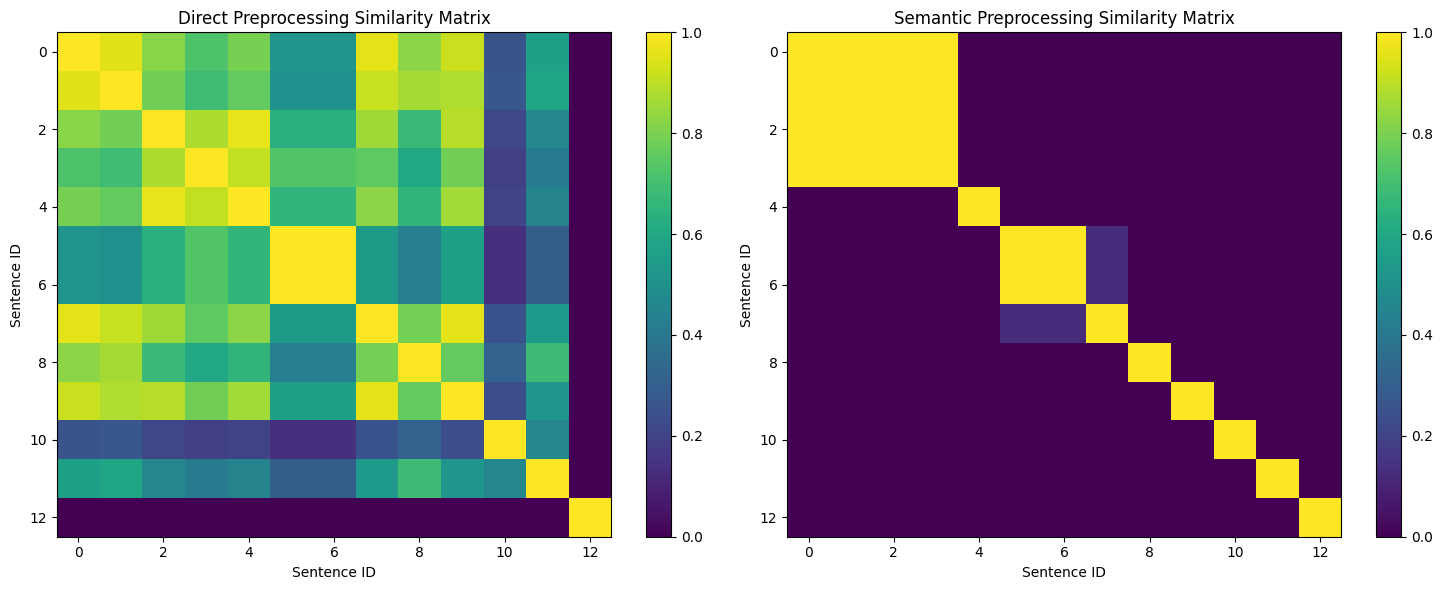

In [19]:
def create_similarity_matrix(sentences, method='direct'):
    """Create similarity matrix between all sentences"""
    n = len(sentences)
    similarity_matrix = np.zeros((n, n))
    
    preprocessor = TextPreprocessor()
    
    for i in range(n):
        for j in range(n):
            if i == j:
                similarity_matrix[i][j] = 1.0
            else:
                if method == 'direct':
                    sent1 = preprocessor.direct_preprocessing(sentences[i])
                    sent2 = preprocessor.direct_preprocessing(sentences[j])
                    # Simple character-based similarity
                    if not sent1 or not sent2:
                        similarity = 0.0
                    else:
                        min_len = min(len(sent1), len(sent2))
                        max_len = max(len(sent1), len(sent2))
                        similarity = min_len / max_len if max_len > 0 else 0.0
                
                elif method == 'semantic':
                    sent1 = preprocessor.semantic_preprocessing(sentences[i])
                    sent2 = preprocessor.semantic_preprocessing(sentences[j])
                    # Jaccard similarity on semantic tokens
                    words1 = set(sent1.split())
                    words2 = set(sent2.split())
                    if not words1 and not words2:
                        similarity = 1.0
                    elif not words1 or not words2:
                        similarity = 0.0
                    else:
                        intersection = words1.intersection(words2)
                        union = words1.union(words2)
                        similarity = len(intersection) / len(union)
                
                similarity_matrix[i][j] = similarity
    
    return similarity_matrix

# Create and visualize similarity matrices
direct_matrix = create_similarity_matrix(test_sentences, 'direct')
semantic_matrix = create_similarity_matrix(test_sentences, 'semantic')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Direct similarity heatmap
im1 = axes[0].imshow(direct_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Direct Preprocessing Similarity Matrix')
axes[0].set_xlabel('Sentence ID')
axes[0].set_ylabel('Sentence ID')
plt.colorbar(im1, ax=axes[0])

# Semantic similarity heatmap
im2 = axes[1].imshow(semantic_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Semantic Preprocessing Similarity Matrix')
axes[1].set_xlabel('Sentence ID')
axes[1].set_ylabel('Sentence ID')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


Key observations:
- Direct similarity catches exact copies but misses paraphrases
- Semantic similarity identifies meaning-based relationships
- Notice how sentences 0-2 (direct copies) are highly similar in both matrices
- Sentences 3-4 (paraphrases) show higher semantic similarity

DATA EXPLORATION SUMMARY

1. TEXT CHARACTERISTICS:
   - Sentence length varies from 0 to 44 characters
   - Word count ranges from 0 to 10 words
   - 10/13 sentences contain punctuation

2. LINGUISTIC FEATURES:
   - Direct preprocessing preserves exact character matching
   - Semantic preprocessing extracts content words (nouns, verbs, adjectives)
   - Syntactic preprocessing normalizes structure while preserving grammar

3. DEPENDENCY PARSING INSIGHTS:
   - Different sentence structures can express the same meaning
   - Dependency trees reveal grammatical relationships
   - Root verbs often indicate the main action of the sentence

4. SIMILARITY PATTERNS:
   - Direct copies show high similarity in both preprocessing methods
   - Paraphrases show low direct similarity but higher semantic similarity
   - Different sentences show low similarity in both methods

5. IMPLICATIONS FOR PLAGIARISM DETECTION:
   - Need multiple similarity measures for comprehensive detection
   - Semantic analy